In [30]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import PCA
from itertools import combinations,chain
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go

In [22]:
import utils
seed = 42 #if it must be 42 :P

(
    wine_X_tr,
    wine_X_val,
    wine_X_test,
    wine_y_tr,
    wine_y_val,
    wine_y_test,
) = utils.get_binned_stratified_data(seed)


In [23]:
plot_kwargs = {'cmap': 'viridis',
               'response_method': 'predict',
               'plot_method': 'pcolormesh',
               'shading': 'auto',
               'alpha': 0.5,
               'grid_resolution': 100}
k = list(range(1,15))
num_features = len(wine_X_tr[0])
features = list(range(num_features))

In [31]:
val_accuracy = []
best_score = 0
f = open("progress_knn_classifier.txt","w")
# go through every combination of feature
for combo in chain.from_iterable(combinations(features,i) for i in range(7,num_features)):
    wine_X_tr_cur = wine_X_tr[:,combo]
    wine_X_val_cur = wine_X_val[:,combo]
    val_accuracy.append([])
    # go through some possible k values
    for i in range(len(k)):
        # fitting and training
        knn = KNeighborsClassifier(n_neighbors=k[i])
        knn.fit(wine_X_tr_cur,wine_y_tr)
        score = knn.score(wine_X_val_cur,wine_y_val)

        val_accuracy[-1].append(score)
        f.write(f"Features: {combo} K: {k[i]} Accuracy: {score}\n")
        if score > best_score:
            best_score = score
            # make it print the best score
            print(f"Features: {combo} K: {k[i]} Accuracy: {score}")
f.close()

Features: (0, 1, 2, 3, 4, 5, 6) K: 1 Accuracy: 0.5135135135135135
Features: (0, 1, 2, 3, 4, 5, 6) K: 2 Accuracy: 0.5608108108108109
Features: (0, 1, 2, 3, 4, 5, 6) K: 3 Accuracy: 0.6013513513513513
Features: (0, 1, 2, 3, 4, 5, 6) K: 8 Accuracy: 0.6148648648648649
Features: (0, 1, 2, 3, 4, 5, 6) K: 11 Accuracy: 0.6554054054054054
Features: (0, 1, 2, 3, 4, 5, 6) K: 12 Accuracy: 0.6621621621621622
Features: (0, 1, 2, 3, 5, 6, 10) K: 6 Accuracy: 0.6756756756756757
Features: (0, 1, 2, 3, 6, 10, 11) K: 7 Accuracy: 0.6824324324324325
Features: (0, 1, 2, 5, 6, 10, 11) K: 4 Accuracy: 0.6891891891891891
Features: (0, 1, 2, 5, 6, 10, 11) K: 5 Accuracy: 0.722972972972973


In [5]:
tr_score = []
val_score = []
best_score = 0
f = open("progress_knn_regressor.txt","w")
for combo in chain.from_iterable(combinations(features,i) for i in range(7,num_features)):
    wine_X_tr_cur = wine_X_tr[:,combo]
    wine_X_val_cur = wine_X_val[:,combo]
    for i in range(len(k)):
        knn = KNeighborsRegressor(n_neighbors=k[i])
        knn.fit(wine_X_tr_cur,wine_y_tr)
        score = knn.score(wine_X_val_cur,wine_y_val)

        tr_score.append(knn.score(wine_X_tr_cur,wine_y_tr))
        val_score.append(score)
        f.write(f"Features: {combo} K: {k[i]} Accuracy: {score}\n")
        if score > best_score:
            best_score = score
            print(f"Features: {combo} K: {k[i]} Accuracy: {score}")
f.close()

Features: (0, 1, 2, 3, 4, 5, 6) K: 2 Accuracy: 0.15715926493108734
Features: (0, 1, 2, 3, 4, 5, 6) K: 3 Accuracy: 0.1878509443593671
Features: (0, 1, 2, 3, 4, 5, 6) K: 4 Accuracy: 0.2628094691168964
Features: (0, 1, 2, 3, 4, 5, 6) K: 5 Accuracy: 0.30268504338948443
Features: (0, 1, 2, 3, 4, 5, 6) K: 6 Accuracy: 0.3169133911859794
Features: (0, 1, 2, 3, 4, 5, 6) K: 7 Accuracy: 0.32854121740579845
Features: (0, 1, 2, 3, 4, 5, 6) K: 8 Accuracy: 0.3339315339458908
Features: (0, 1, 2, 3, 4, 5, 6) K: 9 Accuracy: 0.3431455958255345
Features: (0, 1, 2, 3, 4, 5, 7) K: 8 Accuracy: 0.34853959290454317
Features: (0, 1, 2, 3, 4, 5, 9) K: 9 Accuracy: 0.3514233137340166
Features: (0, 1, 2, 3, 4, 5, 9) K: 10 Accuracy: 0.359346605410924
Features: (0, 1, 2, 3, 4, 5, 9) K: 11 Accuracy: 0.384839625546851
Features: (0, 1, 2, 3, 4, 5, 10) K: 7 Accuracy: 0.38809367544873996
Features: (0, 1, 2, 3, 4, 5, 10) K: 8 Accuracy: 0.4028402565084227
Features: (0, 1, 2, 3, 4, 5, 10) K: 10 Accuracy: 0.4049591628381828
F

Results:
--- Accuracy (train): 73.76%
--- Accuracy (test): 72.30%
0.722972972972973


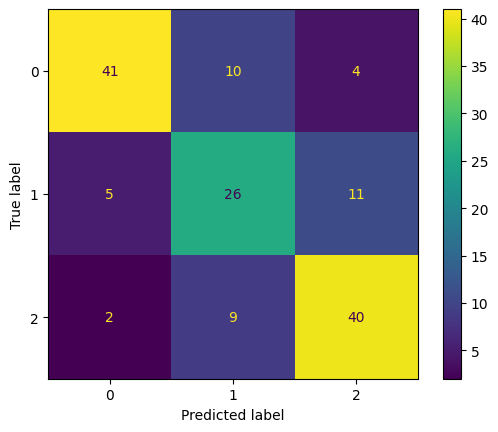

In [28]:
final_combo = [0, 1, 2, 5, 6, 10, 11]
wine_X_tr_cur = wine_X_tr[:,final_combo]
wine_X_val_cur = wine_X_val[:,final_combo]
knn = KNeighborsClassifier(n_neighbors=5)
utils.confusion(knn,wine_X_tr_cur,wine_y_tr,wine_X_val_cur,wine_y_val)
print(knn.score(wine_X_val_cur,wine_y_val))

In [ ]:
fig = go.Figure()
for i,combo in enumerate(chain.from_iterable(combinations(features,i) for i in range(7,num_features))):
    fig.add_trace(go.Scatter(x=k,y=val_accuracy[i],name=str(combo)))
fig.update_layout(title={'text':'Validation Accuracy of kNN Classifier'},xaxis={'title':{'text':'k'}},yaxis={'title':{'text':'accuracy'}})
fig.show()